# 02 — Classical Machine Learning Baselines (1000 per class)

In this notebook, we train the same classical machine learning baselines for wildlife camera-trap image classification on the enriched 1000-per-class dataset.

The goal is to establish simple reference models before moving to deep learning. All models in this notebook use the 1000-per-class train, validation, and test split metadata and the cropped image versions created in the dataset preparation workflow. The cropped images remove most camera-trap border artifacts while keeping the original images unchanged.

We compare simple methods that use manually defined image representations:

- a majority-class baseline,
- Logistic Regression on resized raw pixels,
- HOG features with a Linear SVM classifier.

These baselines help us understand how much predictive signal can be captured without convolutional neural networks.


In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from skimage.feature import hog
from tqdm import tqdm

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
METADATA_DIR = DATA_DIR / "metadata"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train_path = METADATA_DIR / "train_1000.csv"
val_path = METADATA_DIR / "val_1000.csv"
test_path = METADATA_DIR / "test_1000.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(train_df.shape, val_df.shape, test_df.shape)


(5600, 17) (1200, 17) (1200, 17)


## Image input choice

For this 1000-per-class experiment, we use the cropped images generated during dataset preparation.

The original images are preserved in the dataset, but the cropped versions are used for modeling because they reduce the influence of camera-trap text and border artifacts. This makes the baselines focus more on the visual scene itself. When relative cropped paths are available in the metadata, this notebook resolves them from the project root so the experiment is portable across machines.


In [3]:
if "cropped_path_rel" in train_df.columns:
    SOURCE_IMAGE_COL = "cropped_path_rel"

    def resolve_image_path(row):
        image_path = PROJECT_ROOT / row["cropped_path_rel"]
        return image_path
else:
    SOURCE_IMAGE_COL = "cropped_path"

    def resolve_image_path(row):
        image_path = Path(row["cropped_path"])
        if not image_path.is_absolute():
            image_path = PROJECT_ROOT / image_path
        return image_path

assert SOURCE_IMAGE_COL in train_df.columns
assert SOURCE_IMAGE_COL in val_df.columns
assert SOURCE_IMAGE_COL in test_df.columns

for df in (train_df, val_df, test_df):
    df["image_path"] = df.apply(resolve_image_path, axis=1)

IMAGE_COL = "image_path"

print("Using image column:", SOURCE_IMAGE_COL)
print("Resolved image path column:", IMAGE_COL)


Using image column: cropped_path_rel
Resolved image path column: image_path


In [4]:
label_col = "readable_label"

class_names = sorted(train_df[label_col].unique())
class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_class = {idx: class_name for class_name, idx in class_to_id.items()}

class_names

['black_bear',
 'bobcat',
 'coyote',
 'empty',
 'mule_deer',
 'raccoon',
 'red_deer',
 'wild_boar']

In [5]:
y_train = train_df[label_col].map(class_to_id).to_numpy()
y_val = val_df[label_col].map(class_to_id).to_numpy()
y_test = test_df[label_col].map(class_to_id).to_numpy()

print(y_train.shape, y_val.shape, y_test.shape)

(5600,) (1200,) (1200,)


In [6]:
train_df[label_col].value_counts().sort_index()

readable_label
black_bear    700
bobcat        700
coyote        700
empty         700
mule_deer     700
raccoon       700
red_deer      700
wild_boar     700
Name: count, dtype: int64

In [7]:
def load_resized_image(path, size=(64, 64)):
    """
    Load an image, convert to RGB, resize it, and return it as a NumPy array.
    size follows PIL convention: (width, height).
    """
    image = Image.open(path).convert("RGB")
    image = image.resize(size)
    return np.asarray(image)

In [8]:
def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, class_names):
    """
    Train a sklearn model and evaluate it on validation data.
    """
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")

    print(f"{model_name}")
    print(f"Validation accuracy: {accuracy:.4f}")
    print(f"Validation macro-F1:  {macro_f1:.4f}")
    print(f"Training time:        {train_time:.2f} seconds")
    print()
    print(classification_report(y_val, y_pred, target_names=class_names))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "train_time_seconds": train_time,
        "y_pred": y_pred,
        "fitted_model": model,
    }

In [9]:
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    fig, ax = plt.subplots(figsize=(8, 8))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=class_names,
        xticks_rotation=45,
        cmap=None,
        ax=ax,
    )

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Majority-class baseline

We first train a dummy classifier that always predicts the most frequent class in the training set.

Since the 1000-per-class dataset is balanced across the 8 classes, this baseline should perform close to random guessing. It provides a sanity check and establishes the minimum reference point that all real models should exceed.


In [10]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_result = evaluate_model(
    model_name="majority_class",
    model=dummy_model,
    X_train=np.zeros((len(y_train), 1)),
    y_train=y_train,
    X_val=np.zeros((len(y_val), 1)),
    y_val=y_val,
    class_names=class_names,
)

majority_class
Validation accuracy: 0.1250
Validation macro-F1:  0.0278
Training time:        0.00 seconds

              precision    recall  f1-score   support

  black_bear       0.12      1.00      0.22       150
      bobcat       0.00      0.00      0.00       150
      coyote       0.00      0.00      0.00       150
       empty       0.00      0.00      0.00       150
   mule_deer       0.00      0.00      0.00       150
     raccoon       0.00      0.00      0.00       150
    red_deer       0.00      0.00      0.00       150
   wild_boar       0.00      0.00      0.00       150

    accuracy                           0.12      1200
   macro avg       0.02      0.12      0.03      1200
weighted avg       0.02      0.12      0.03      1200



/Users/mihnea/Desktop/Proiecte personale/wildlife-camera-trap-classification/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mihnea/Desktop/Proiecte personale/wildlife-camera-trap-classification/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mihnea/Desktop/Proiecte personale/wildlife-camera-trap-classification/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being se

## Resized pixels + Logistic Regression

This baseline uses the cropped images directly as raw pixel information.

Each image is resized to 64×64 pixels, normalized to the `[0, 1]` range, and flattened into a one-dimensional vector. A Logistic Regression classifier is then trained on these vectors.

This is a simple linear baseline. It does not explicitly model edges, shapes, object parts, or spatial invariance, but it tests whether coarse color and intensity patterns contain enough signal to distinguish the classes.

In [11]:
def extract_raw_pixel_features(df, image_col=IMAGE_COL, size=(64, 64)):
    """
    Convert images into flattened resized pixel vectors.
    
    Example:
    64 x 64 x 3 = 12,288 features per image.
    """
    features = []

    for path in tqdm(df[image_col], desc="Extracting raw pixel features"):
        image_array = load_resized_image(path, size=size)
        image_array = image_array.astype("float32") / 255.0
        features.append(image_array.flatten())

    return np.vstack(features)

In [12]:
X_train_pixels = extract_raw_pixel_features(train_df, image_col=IMAGE_COL, size=(64, 64))
X_val_pixels = extract_raw_pixel_features(val_df, image_col=IMAGE_COL, size=(64, 64))

print(X_train_pixels.shape)
print(X_val_pixels.shape)

Extracting raw pixel features: 100%|██████████| 1200/1200 [00:15<00:00, 79.42it/s]

(5600, 12288)
(1200, 12288)


In [13]:
pixel_logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        class_weight=None,
        random_state=42,
    ),
)

pixel_logreg_result = evaluate_model(
    model_name="resized_pixels_logistic_regression",
    model=pixel_logreg,
    X_train=X_train_pixels,
    y_train=y_train,
    X_val=X_val_pixels,
    y_val=y_val,
    class_names=class_names,
)

resized_pixels_logistic_regression
Validation accuracy: 0.4958
Validation macro-F1:  0.4961
Training time:        29.50 seconds

              precision    recall  f1-score   support

  black_bear       0.53      0.48      0.50       150
      bobcat       0.43      0.43      0.43       150
      coyote       0.44      0.45      0.44       150
       empty       0.46      0.51      0.48       150
   mule_deer       0.61      0.51      0.56       150
     raccoon       0.57      0.67      0.62       150
    red_deer       0.58      0.43      0.50       150
   wild_boar       0.40      0.49      0.44       150

    accuracy                           0.50      1200
   macro avg       0.50      0.50      0.50      1200
weighted avg       0.50      0.50      0.50      1200



/Users/mihnea/Desktop/Proiecte personale/wildlife-camera-trap-classification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


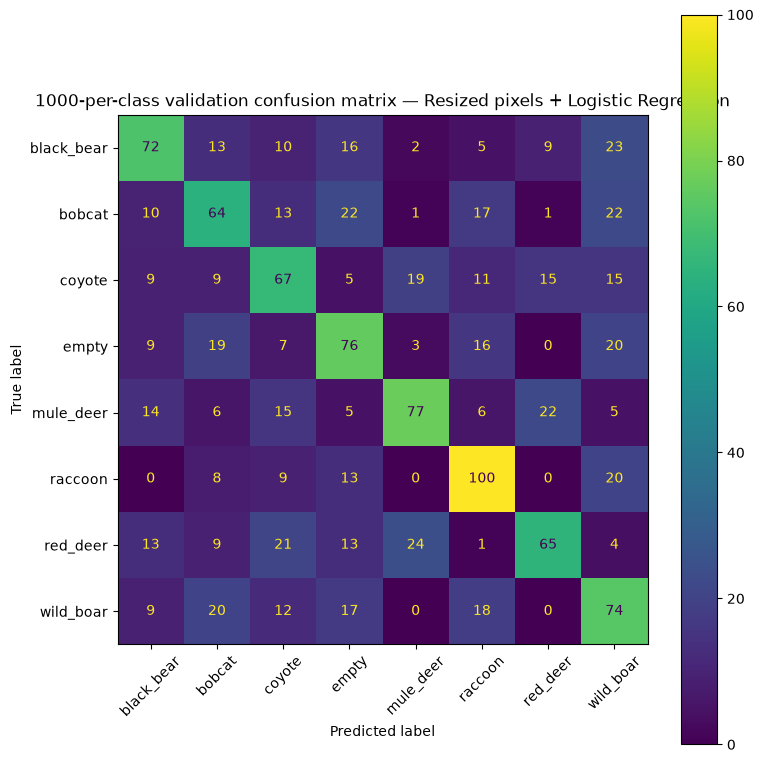

In [14]:
plot_confusion_matrix(
    y_true=y_val,
    y_pred=pixel_logreg_result["y_pred"],
    class_names=class_names,
    title="1000-per-class validation confusion matrix — Resized pixels + Logistic Regression",
)


### Interpretation: resized pixels + Logistic Regression

The resized-pixel Logistic Regression model reaches 0.4958 validation accuracy and 0.4961 macro-F1. This is well above the majority-class baseline, so the resized RGB images contain useful class-specific signal even before using more advanced computer vision models. Some classes are easier to separate from global color and texture patterns, while others require more detailed shape or object-level information.

The model still has clear limitations. Since each image is flattened into a vector, Logistic Regression cannot properly use local structure, object position, or spatial relationships. This is especially problematic for camera-trap images, where the animal may be small, off-center, partially occluded, or visually mixed with the background.

## HOG features + Linear SVM

The next baseline uses Histogram of Oriented Gradients (HOG) features instead of raw pixel values.

HOG summarizes local edge directions and gradient patterns in the image. This representation is designed to capture shape and contour information, which may be useful for distinguishing animals by body outline, posture, legs, ears, and other structural cues.

After extracting HOG features from each cropped image, we train a Linear SVM classifier. This is a standard classical computer vision pipeline: handcrafted visual features followed by a margin-based linear classifier.

In [15]:
def extract_hog_features(df, image_col=IMAGE_COL, size=(128, 128)):
    """
    Transform each image into a HOG feature vector after resizing and converting to grayscale.
    """
    features = []

    for path in tqdm(df[image_col], desc="Extracting HOG features"):
        image = Image.open(path).convert("L")
        image = image.resize(size)

        image_array = np.asarray(image)

        hog_vector = hog(
            image_array,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True,
        )

        features.append(hog_vector)

    return np.vstack(features)

In [16]:
X_train_hog = extract_hog_features(train_df, image_col=IMAGE_COL, size=(128, 128))
X_val_hog = extract_hog_features(val_df, image_col=IMAGE_COL, size=(128, 128))

print("Train HOG shape:", X_train_hog.shape)
print("Validation HOG shape:", X_val_hog.shape)

Extracting HOG features: 100%|██████████| 1200/1200 [00:11<00:00, 107.43it/s]

Train HOG shape: (5600, 8100)
Validation HOG shape: (1200, 8100)


In [17]:
hog_svm = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        class_weight=None,
        random_state=42,
        max_iter=5000,
    ),
)

In [18]:
hog_svm_result = evaluate_model(
    model_name="hog_linear_svm",
    model=hog_svm,
    X_train=X_train_hog,
    y_train=y_train,
    X_val=X_val_hog,
    y_val=y_val,
    class_names=class_names,
)

hog_linear_svm
Validation accuracy: 0.4250
Validation macro-F1:  0.4260
Training time:        258.74 seconds

              precision    recall  f1-score   support

  black_bear       0.46      0.44      0.45       150
      bobcat       0.34      0.37      0.36       150
      coyote       0.45      0.40      0.43       150
       empty       0.36      0.41      0.38       150
   mule_deer       0.52      0.54      0.53       150
     raccoon       0.51      0.45      0.48       150
    red_deer       0.47      0.47      0.47       150
   wild_boar       0.32      0.32      0.32       150

    accuracy                           0.42      1200
   macro avg       0.43      0.43      0.43      1200
weighted avg       0.43      0.42      0.43      1200



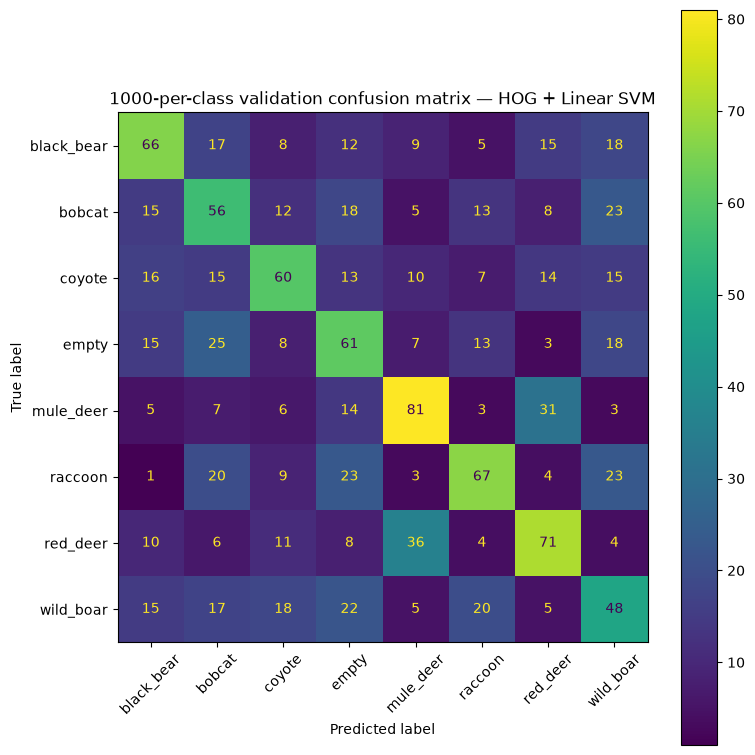

In [19]:
plot_confusion_matrix(
    y_true=y_val,
    y_pred=hog_svm_result["y_pred"],
    class_names=class_names,
    title="1000-per-class validation confusion matrix — HOG + Linear SVM",
)


### Interpretation: HOG + Linear SVM

The HOG + Linear SVM model performs clearly above the majority-class baseline, but below the resized-pixel Logistic Regression baseline. It reaches 0.4250 validation accuracy and 0.4260 macro-F1, showing that edge and gradient structure contains useful information, but is not sufficient for strong classification on this dataset.

The class-level results are fairly balanced, but no class is classified very strongly. Mule deer, raccoon, and red deer perform better than the most difficult classes, while wild boar and bobcat remain harder.

The result suggests that handcrafted shape features are limited for camera-trap images. Since HOG is computed over the full image, it can capture background edges, vegetation, shadows, and terrain texture in addition to animal contours. This makes it less reliable when animals are small, partially visible, or blended into the scene.


## Visual inspection of HOG + Linear SVM errors

We visualize some example to see why HOG features fail to improve the performance.

In [20]:
from skimage import exposure

def show_hog_visualization(path, size=(128, 128)):

    image = Image.open(path).convert("L")

    image = image.resize(size)

    image_array = np.asarray(image)

    hog_vector, hog_image = hog(
        image_array,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True,
    )

    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(image_array, cmap="gray")
    axes[0].set_title("Resized grayscale image")
    axes[0].axis("off")
    axes[1].imshow(hog_image_rescaled, cmap="gray")
    axes[1].set_title("HOG visualization")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

empty


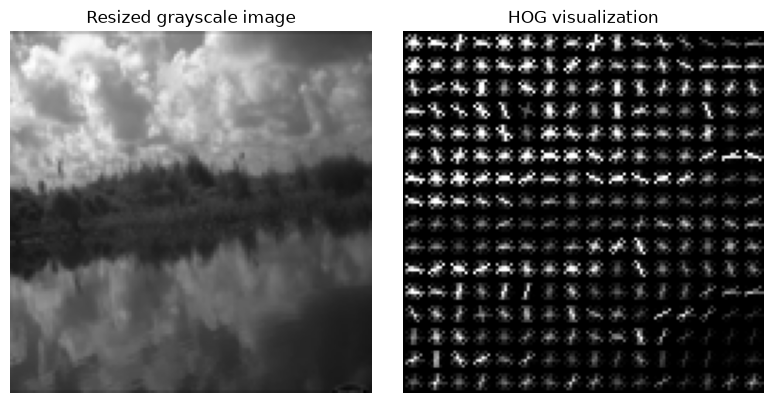

black_bear


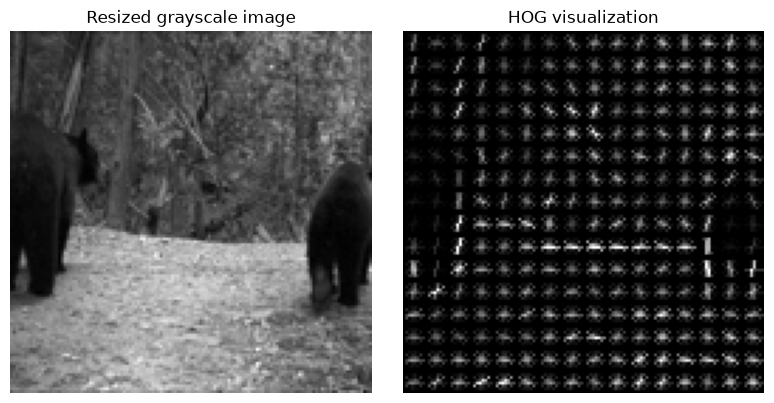

coyote


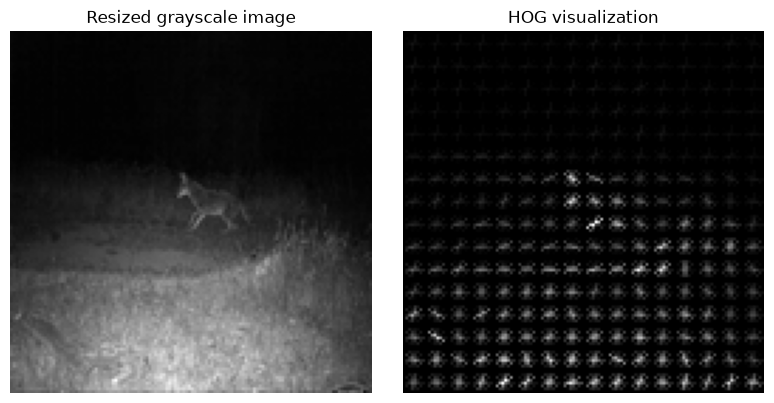

coyote


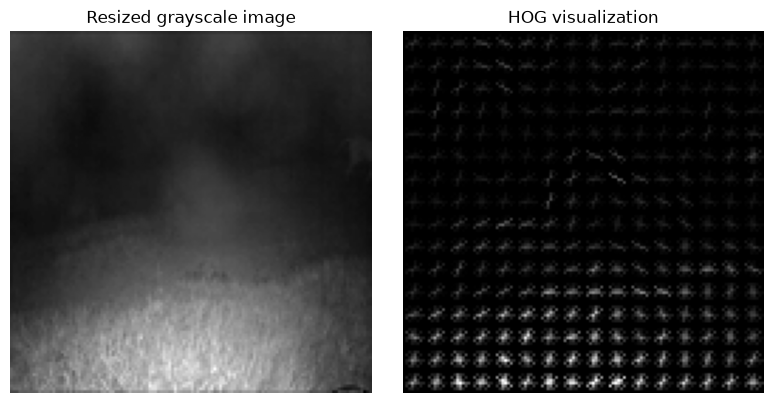

red_deer


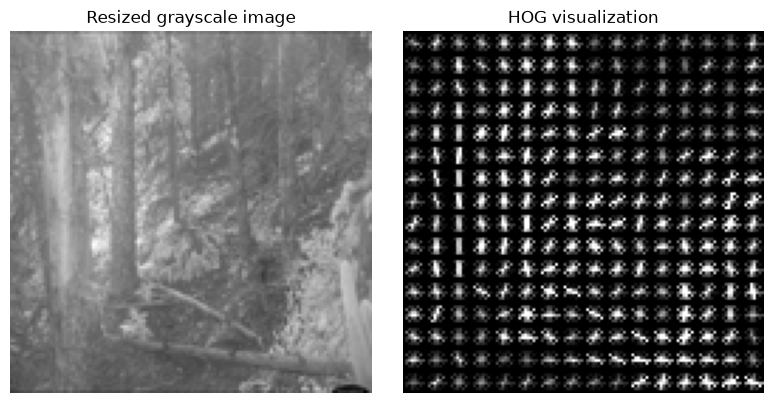

In [21]:
sample_df = val_df.sample(5, random_state=42)

for _, row in sample_df.iterrows():
    print(row["readable_label"])
    show_hog_visualization(row[IMAGE_COL])

### Visual interpretation of HOG errors

The HOG visualizations suggest that the descriptor is often dominated by background structure rather than animal-specific shape. In these examples, strong gradients appear across trees, snow, shadows, ground texture, and vegetation, while the animal occupies only a small part of the image.

This makes the final HOG vector a mixture of animal contours and scene-level edge patterns. Since HOG is computed globally over the whole image and does not know where the animal is located, the Linear SVM may learn background texture as much as class-relevant animal shape. This helps explain why HOG features perform weakly on this camera-trap dataset.

## Adding color information to HOG

HOG features describe edge and gradient structure, but they are computed on grayscale images and therefore discard color information.

Since the resized-pixel Logistic Regression baseline keeps RGB information and performs better than HOG alone, we test whether adding a simple color descriptor helps. For this check, we concatenate HOG features with RGB color histograms and train the same Linear SVM classifier.

This is not intended as a heavily optimized model. It is a small diagnostic experiment to see whether the weak HOG performance is partly due to the loss of color information.

In [22]:
def extract_color_histogram_features(
    df,
    image_col=IMAGE_COL,
    size=(128, 128),
    bins=16,
):
    """
    Extract simple RGB color histogram features.

    Each image is resized, then one normalized histogram is computed
    for each RGB channel. The final feature vector has 3 * bins values.
    """
    features = []

    for path in tqdm(df[image_col], desc="Extracting color histograms"):
        image = Image.open(path).convert("RGB")
        image = image.resize(size)
        image_array = np.asarray(image)

        hist_features = []

        for channel in range(3):
            hist, _ = np.histogram(
                image_array[:, :, channel],
                bins=bins,
                range=(0, 256),
                density=True,
            )
            hist_features.extend(hist)

        features.append(hist_features)

    return np.asarray(features)

In [23]:
X_train_color = extract_color_histogram_features(train_df, image_col=IMAGE_COL)
X_val_color = extract_color_histogram_features(val_df, image_col=IMAGE_COL)

print("Train color shape:", X_train_color.shape)
print("Validation color shape:", X_val_color.shape)

Extracting color histograms: 100%|██████████| 1200/1200 [00:27<00:00, 43.87it/s]

Train color shape: (5600, 48)
Validation color shape: (1200, 48)


In [24]:
X_train_hog_color = np.hstack([X_train_hog, X_train_color])
X_val_hog_color = np.hstack([X_val_hog, X_val_color])

print("Train HOG + color shape:", X_train_hog_color.shape)
print("Validation HOG + color shape:", X_val_hog_color.shape)

Train HOG + color shape: (5600, 8148)
Validation HOG + color shape: (1200, 8148)


In [25]:
hog_color_svm = make_pipeline(
    StandardScaler(),
    LinearSVC(
        C=1.0,
        class_weight=None,
        random_state=42,
        max_iter=5000,
    ),
)

hog_color_svm_result = evaluate_model(
    model_name="hog_color_linear_svm",
    model=hog_color_svm,
    X_train=X_train_hog_color,
    y_train=y_train,
    X_val=X_val_hog_color,
    y_val=y_val,
    class_names=class_names,
)

hog_color_linear_svm
Validation accuracy: 0.4425
Validation macro-F1:  0.4443
Training time:        436.62 seconds

              precision    recall  f1-score   support

  black_bear       0.49      0.48      0.49       150
      bobcat       0.35      0.39      0.37       150
      coyote       0.48      0.45      0.46       150
       empty       0.37      0.41      0.39       150
   mule_deer       0.56      0.56      0.56       150
     raccoon       0.53      0.46      0.49       150
    red_deer       0.51      0.49      0.50       150
   wild_boar       0.30      0.30      0.30       150

    accuracy                           0.44      1200
   macro avg       0.45      0.44      0.44      1200
weighted avg       0.45      0.44      0.44      1200



### Interpretation: HOG + color histograms

Adding RGB color histograms to HOG improves the Linear SVM slightly, from 0.4250 to 0.4425 validation accuracy and from 0.4260 to 0.4443 macro-F1. This suggests that color provides some complementary information beyond grayscale edge structure.

However, the improvement is modest. The model still remains below the resized-pixel Logistic Regression baseline, which indicates that the main limitation is not only the loss of color, but the handcrafted nature of the representation.

The strongest classes remain mule deer, red deer, raccoon, and black bear, while wild boar and bobcat remain more difficult. Overall, HOG + color is a useful diagnostic baseline, but it does not appear to be a strong final approach for this dataset.
